# CodeBERTScore Plots (from precomputed stats)
Load ablation-results_statistics.csv and render box-style summaries without recalculating metrics.

In [149]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import numpy as np
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = [12, 6]

MODEL_LABELS = {
    "gpt5": "GPT-5",
    "phi4": "Phi4",
    "qw32": "Qw32B",
}
# Custom brand colors with fallbacks for unspecified models
OVERRIDE_COLORS = {
    "qw32": "#9289E8",
    "gpt5": "#70A597",
    "phi4": "#689DDD",
}
PROCESSOR_LABELS = {"dp": "DP", "mc": "MC", "sg": "ArdSG", "psg": "PySG-CPU", "tpusg": "PySG-TPU"}
PROMPT_LABELS = {
    "original": "Prompt Original",
    "abla-l1": "Prompt L1",
    "abla-l2": "Prompt L2",
    "abla-1p": "Prompt L1-P",
    "abla-2p": "Prompt L2-P",
}


palette = sns.color_palette("tab20", n_colors=len(MODEL_LABELS))
MODEL_COLORS = {}
for i, m in enumerate(MODEL_LABELS.keys()):
    MODEL_COLORS[m] = OVERRIDE_COLORS.get(m, palette[i % len(palette)])

NOTEBOOK_DIR = Path.cwd()
STATS_PATH_CANDIDATES = [
    NOTEBOOK_DIR / "ablation-results_statistics.csv",
    NOTEBOOK_DIR.parent / "plottings" / "ablation-results_statistics.csv",
    NOTEBOOK_DIR / "analyser-results" / "ablation-results_statistics.csv",
]

STATS_FILE = next((p for p in STATS_PATH_CANDIDATES if p.exists()), None)
if STATS_FILE is None:
    raise FileNotFoundError("ablation-results_statistics.csv not found in expected locations.")

stats = pd.read_csv(STATS_FILE)
print(f"Loaded {len(stats)} rows from {STATS_FILE}")
print(f"Metrics: {sorted(stats['metric'].unique())}")
print(f"Prompt levels: {sorted(stats['Prompt_level'].unique())}")
print(f"Processors: {sorted(stats['Processor'].unique())}")

metrics = sorted(stats["metric"].unique())
processors = sorted(stats["Processor"].unique())
prompt_levels_seen = list(stats["Prompt_level"].unique())
prompts = [p for p in PROMPT_LABELS if p in prompt_levels_seen]
extra_prompts = [p for p in prompt_levels_seen if p not in PROMPT_LABELS]
prompts += sorted(extra_prompts)

stats.head()

Loaded 104 rows from /home/han/Projects/benchmark-tinyml_llm-2026/codebertscore-similarity/analyser-results/ablation-results_statistics.csv
Metrics: ['F1', 'F3', 'Precision', 'Recall']
Prompt levels: ['abla-1p', 'abla-2p', 'abla-l1', 'abla-l2', 'original']
Processors: ['psg', 'sg', 'tpusg']


,metric,Model,Prompt_level,Processor,count,mean,median,std,min,Q1,Q3,max,IQR,lower_whisker,upper_whisker,outlier_count
0,Precision,gpt5,abla-l1,psg,30,0.826513,0.827300,0.010443,0.807427,0.818332,0.834930,0.847317,0.016598,0.807427,0.847317,0
1,Precision,gpt5,abla-l1,sg,3,0.831381,0.836078,0.013932,0.815708,0.825893,0.839218,0.842357,0.013324,0.815708,0.842357,0
2,Precision,gpt5,abla-l1,tpusg,30,0.810734,0.816312,0.014359,0.783676,0.797119,0.819960,0.834903,0.022841,0.783676,0.834903,0
3,Precision,gpt5,abla-l2,psg,30,0.798674,0.799578,0.013972,0.776612,0.788429,0.806920,0.821753,0.018491,0.776612,0.821753,0
4,Precision,gpt5,abla-l2,sg,21,0.819970,0.816256,0.009968,0.807338,0.813042,0.824660,0.839926,0.011618,0.807338,0.839926,0


Helper to convert precomputed statistics into matplotlib.bxp input.

In [150]:
BOX_KWARGS = {
    "medianprops": {"color": "black", "linewidth": 2},
    "meanprops": {"marker": "x", "markeredgecolor": "black", "markersize": 7, "linestyle": "none"},
    "whiskerprops": {"color": "black", "linewidth": 1.5},
    "capprops": {"color": "black", "linewidth": 1.5},
    "boxprops": {"edgecolor": "black", "linewidth": 1.5},
}

def make_bxp_rows(subset: pd.DataFrame):
    subset = subset.sort_values("Model")
    bxp_rows = []
    colors = []
    model_order = []
    for _, row in subset.iterrows():
        bxp_rows.append({
            "label": MODEL_LABELS.get(row["Model"], row["Model"]),
            "med": row["median"],
            "q1": row["Q1"],
            "q3": row["Q3"],
            "whislo": row["lower_whisker"],
            "whishi": row["upper_whisker"],
            "mean": row["mean"],
            "fliers": [],
        })
        colors.append(MODEL_COLORS.get(row["Model"], "lightgray"))
        model_order.append(row["Model"])

    return bxp_rows, colors, model_order

def apply_box_colors(artists, colors):
    for patch, color in zip(artists["boxes"], colors):
        patch.set_facecolor(color)

def set_axis_limits(ax, subset, pad_frac=0.05):
    y_min = subset["lower_whisker"].min()
    y_max = subset["upper_whisker"].max()
    y_range = y_max - y_min if y_max > y_min else 0.05
    ax.set_ylim(max(0, y_min - pad_frac * y_range), min(1, y_max + pad_frac * y_range))

### Prompt-level comparison per processor
For each processor, compare prompt levels side-by-side (boxes per model) with per-plot y-limits.

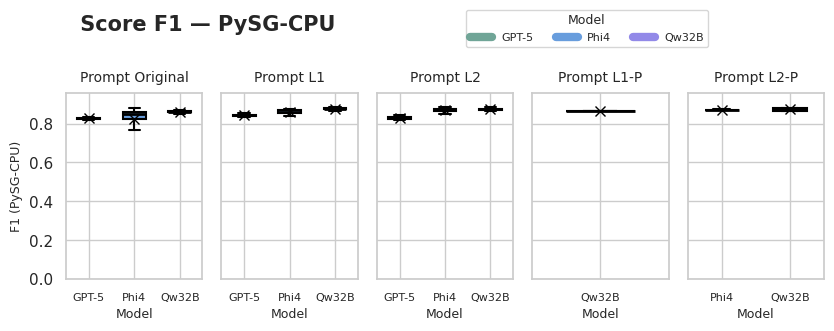

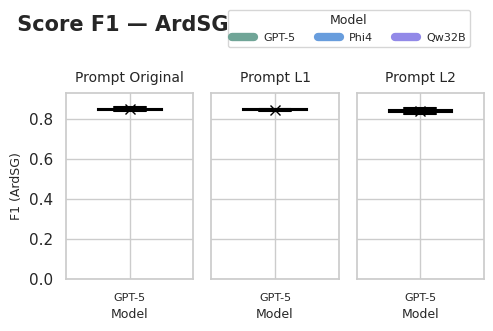

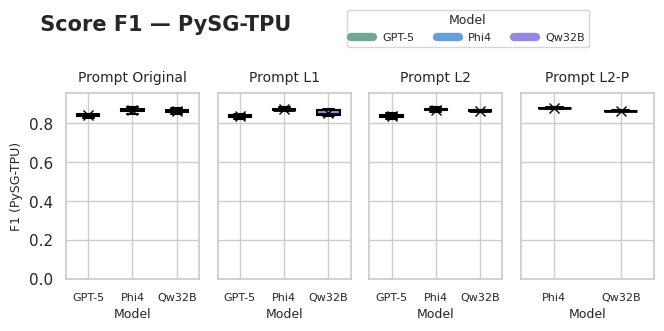

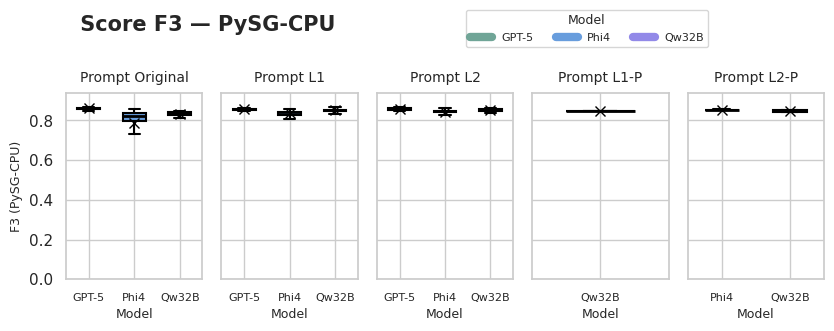

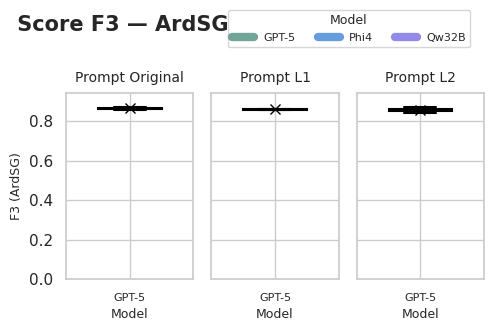

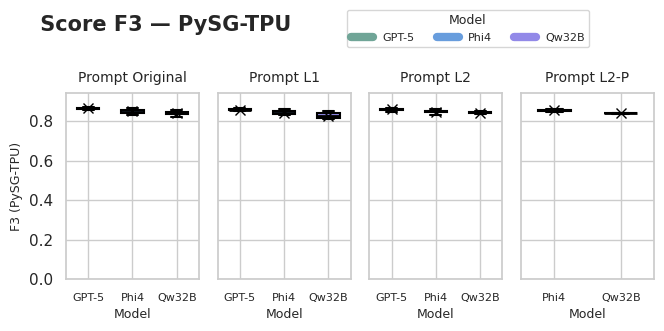

In [151]:
def plot_by_processor(metric, proc):
    prompt_slots = []
    for p in prompts:
        subset = stats[(stats["metric"] == metric) & (stats["Processor"] == proc) & (stats["Prompt_level"] == p)]
        if not subset.empty:
            prompt_slots.append(p)
    if not prompt_slots:
        print(f"No data for {metric} / {proc}; skipping plot.")
        return
    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(prompt_slots),
        figsize=(len(prompt_slots) * 1.7, 3.6),
        sharey=True,
    )
    axes = np.array(axes).reshape(1, len(prompt_slots))[0]
    legend_handles = [Line2D([0], [0], color=MODEL_COLORS[m], lw=6) for m in MODEL_LABELS]
    legend_labels = [MODEL_LABELS[m] for m in MODEL_LABELS]

    # Compute shared y limits across all prompts for this metric+processor; anchor at 0
    all_subsets = stats[(stats["metric"] == metric) & (stats["Processor"] == proc)]
    if not all_subsets.empty:
        y_max_global = all_subsets["upper_whisker"].max()
        y_range_global = y_max_global if y_max_global > 0 else 0.05
        y_lo = 0
        y_hi = min(1, y_max_global + 0.08 * y_range_global)

    for j, prompt in enumerate(prompt_slots):
        ax = axes[j]
        subset = stats[(stats["metric"] == metric) & (stats["Processor"] == proc) & (stats["Prompt_level"] == prompt)]
        bxp_rows, colors, model_order = make_bxp_rows(subset)
        artists = ax.bxp(
            bxp_rows,
            showfliers=False,
            showmeans=True,
            patch_artist=True,
            widths=0.5,
            **BOX_KWARGS,
        )
        apply_box_colors(artists, colors)
        labels = [MODEL_LABELS.get(m, m) for m in model_order]
        ax.set_xticklabels(labels, fontsize=8)
        ax.set_title(PROMPT_LABELS.get(prompt, prompt), fontsize=10, pad=8)
        ax.set_xlabel("Model", fontsize=9)
        if j == 0:
            ax.set_ylabel(f"{metric} ({PROCESSOR_LABELS.get(proc, proc)})", fontsize=9)
        else:
            ax.set_ylabel("")
            ax.tick_params(labelleft=False)
        if not all_subsets.empty:
            ax.set_ylim(y_lo, y_hi)
    fig.suptitle(
        f" Score {metric} — {PROCESSOR_LABELS.get(proc, proc)}",
        fontsize=15,
        fontweight="bold",
        y=0.9,
        x=0.25
    )
    fig.legend(legend_handles, legend_labels, title="Model", ncol=len(legend_labels), loc="upper center", fontsize=8, title_fontsize=9, bbox_to_anchor=(0.7, 0.93))
    fig.tight_layout(rect=[0, 0, 1, 0.9])
    plt.show()

for metric in ['F1', 'F3']:
    for proc in processors:
        plot_by_processor(metric, proc)

### Global min/max values across all statistics
Find the absolute lowest and highest numeric values present in ablation-results_statistics.csv, with context rows.

In [152]:
import numpy as np

numeric_cols = stats.select_dtypes(include=[np.number]).columns
min_idx = stats[numeric_cols].stack().idxmin()
max_idx = stats[numeric_cols].stack().idxmax()

min_row_label, min_col = min_idx
max_row_label, max_col = max_idx

min_row = stats.loc[min_row_label]
max_row = stats.loc[max_row_label]

print("=== Global minimum across all numeric fields ===")
print(f"Value: {stats.at[min_row_label, min_col]:.6f} (column: {min_col})")
print(min_row[['metric', 'Model', 'Prompt_level', 'Processor']])
print()
print("=== Global maximum across all numeric fields ===")
print(f"Value: {stats.at[max_row_label, max_col]:.6f} (column: {max_col})")
print(max_row[['metric', 'Model', 'Prompt_level', 'Processor']])

=== Global minimum across all numeric fields ===
Value: 0.000000 (column: outlier_count)
metric          Precision
Model                gpt5
Prompt_level      abla-l1
Processor             psg
Name: 0, dtype: object

=== Global maximum across all numeric fields ===
Value: 48.000000 (column: count)
metric          Precision
Model                phi4
Prompt_level      abla-2p
Processor           tpusg
Name: 10, dtype: object
